In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

import lightgbm as lgb

In [18]:
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,loan_amount,annual_income,total_balance,total_credit_limit,total_monthly_debt,monthly_income,age,past_delinquencies,default
0,20795,61656,15873,26633,1602,5138.000000,45,4,1
1,5860,97695,14016,44660,1097,8141.250000,38,2,1
2,16284,67900,1153,13439,2159,5658.333333,26,3,1
3,11265,114899,8853,42172,3773,9574.916667,38,0,0
4,21850,77701,13379,45622,2185,6475.083333,36,0,0


In [21]:
df['credit_utilization'] = df['total_balance'] / df['total_credit_limit']

In [22]:
df['dti'] = df['total_monthly_debt'] / df['monthly_income']

In [23]:
df['loan_income_ratio'] = df['loan_amount'] / df['annual_income']

In [24]:
X = df.drop(columns=['default'])
y = df['default']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [29]:
y_pred_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [30]:
auc_log = roc_auc_score(y_test, y_pred_proba_log)
print("Logistic Regression AUC:", auc_log)

gini_log = 2 * auc_log - 1
print("Logistic Regression Gini:", gini_log)

Logistic Regression AUC: 0.7897466857227342
Logistic Regression Gini: 0.5794933714454684


In [31]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 918, number of negative: 482
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000628 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2348
[LightGBM] [Info] Number of data points in the train set: 1400, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=300,
               random_state=42)

In [32]:
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

In [33]:
auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
print("LightGBM AUC:", auc_lgb)

gini_lgb = 2 * auc_lgb - 1
print("LightGBM Gini:", gini_lgb)

LightGBM AUC: 0.7429402198018825
LightGBM Gini: 0.48588043960376504


In [35]:
auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
print("LightGBM AUC:", auc_lgb)

gini_lgb = 2 * auc_lgb - 1
print("LightGBM Gini:", gini_lgb)

LightGBM AUC: 0.7429402198018825
LightGBM Gini: 0.48588043960376504


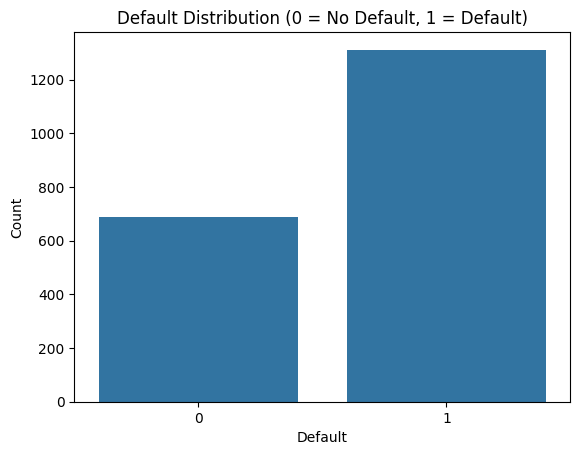

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(x=y)
plt.title("Default Distribution (0 = No Default, 1 = Default)")
plt.xlabel("Default")
plt.ylabel("Count")
plt.show()

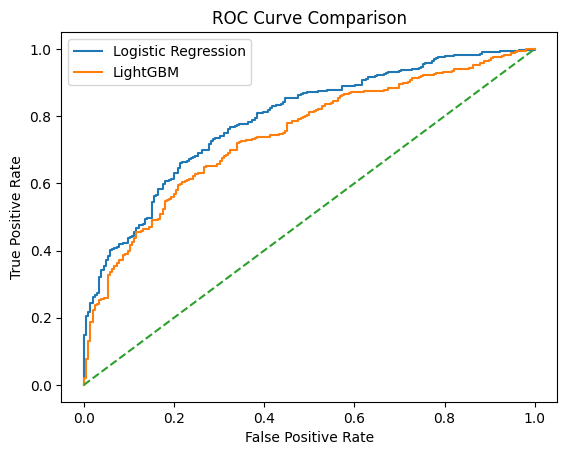

In [39]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_proba_lgb)

plt.figure()
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_lgb, tpr_lgb, label="LightGBM")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

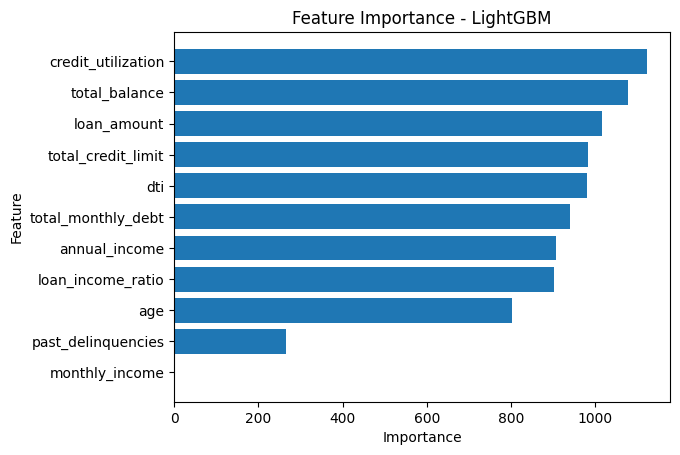

In [40]:
importances = lgb_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - LightGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

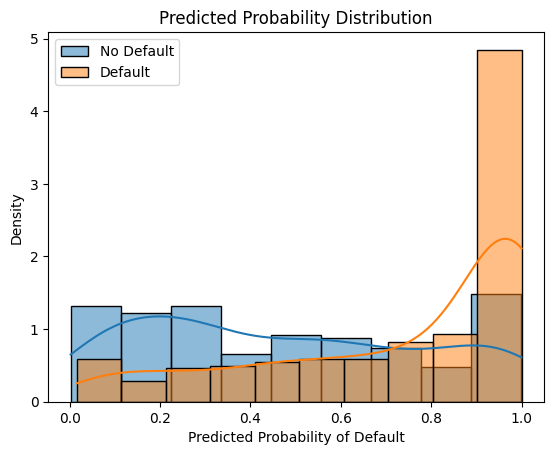

In [41]:
plt.figure()
sns.histplot(y_pred_proba_lgb[y_test==0], label="No Default", kde=True, stat="density")
sns.histplot(y_pred_proba_lgb[y_test==1], label="Default", kde=True, stat="density")
plt.legend()
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted Probability of Default")
plt.show()